# Step 2 — Standard Flow Matching

**A Computer Vision Project — *Flow Matching as a Layer*** · Stage 2
University of Haifa

---

## Purpose

Train the velocity network $v_\theta(z, t)$ with the **standard** flow-matching objective and
measure what the FM layer does to classification accuracy, against the Stage 1 prototype
baseline reproduced in step 1.

For each training feature $\hat z_i$ (L2-normalized) and its class prototype $p_{y_i}$, draw
$t \sim \mathcal{U}(0,1)$, place a point on the straight line between them, and ask the
network to predict the constant velocity of that line:

$$z_t = (1-t)\,\hat z_i + t\,p_{y_i}, \qquad u_i = p_{y_i} - \hat z_i,
\qquad \mathcal{L}_\mathrm{FM} = \lVert v_\theta(z_t, t) - u_i \rVert_2^2$$

At inference the feature is transported by $T$ Euler steps and classified with Stage 1's
unchanged cosine rule.

## The mismatch this objective has

Training only ever visits points **on** the ideal straight path. Inference feeds the network
states generated by its *own* previous predictions, which drift off that path. Nothing in
this objective teaches the network how to recover from its own error — that is precisely what
step 3's rolled-out training addresses, and why the two are compared.

## Standard FM training does not depend on $T$

No rollout happens during training, so **one trained model is evaluated at every $T$**. That
is why this step trains 27 models (3 combinations x 3 $K$ x 3 seeds) and reports 54 accuracy
numbers ($\times$ 2 values of $T$), while step 3 will need a separate model per $T$.

## Sections

| # | Section |
| --- | --- |
| 1 | Setup |
| 2 | The velocity network |
| 3 | What the objective actually supervises |
| 4 | Train the 27 models |
| 5 | Results against the Stage 1 baseline |
| 6 | Training curves — stability |
| 7 | Save artefacts |
| 8 | Manifest |

## 1 · Setup

The prototypes come from step 1's `results/prototypes.pt` — already verified to reproduce the
Stage 1 baseline exactly. Features are the same Stage 1 cache, read-only; no encoder is run
here either.

In [1]:
from __future__ import annotations

import json
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from cvlab.data import make_kshot_subset
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab.prototypes import l2_normalize

from cvlabfm.flow import (FlowConfig, VelocityNet, classify_by_prototype, euler_rollout,
                          evaluate_flow, train_standard_fm)
from cvlabfm.paths import RESULTS_ROOT, STAGE1_RESULTS, step_dirs

apply_style()
art = ArtifactWriter(*step_dirs("02_standard_fm"))

COMBOS: list[tuple[str, str]] = [
    ("resnet18", "DTD"),
    ("resnet18", "FGVC-Aircraft"),
    ("dinov2", "FGVC-Aircraft"),
]
K_SETTINGS: list[int | str] = [5, 10, "full"]
SEEDS: list[int] = [0, 1, 2]
T_VALUES: list[int] = [4, 12]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG = FlowConfig()          # the fixed configuration, shared with step 3

# Representative runs whose trained weights are kept for step 5's visualisations.
REPRESENTATIVE = {(enc, ds, "full", 0) for enc, ds in COMBOS}

print(f"device : {DEVICE}")
print(f"config : {CONFIG.as_dict()}")

device : cuda
config : {'hidden_dim': 512, 'n_hidden': 2, 'activation': 'SiLU', 'optimizer': 'AdamW', 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'epochs': 100, 'max_grad_norm': 1.0, 'checkpoint_selection': 'none - final epoch, fixed budget'}


In [2]:
# Step 1's prototypes, and the Stage 1 baseline they were verified against.
proto_payload = torch.load(RESULTS_ROOT / "prototypes.pt", weights_only=False)
prototypes = proto_payload["prototypes"]
print(f"loaded {len(prototypes)} prototype sets  "
      f"({proto_payload['meta']['verified_against']})")


def proto_key(encoder: str, dataset: str, K, seed) -> str:
    '''Full-data prototypes are seed-independent (step 1), so all three FM seeds
    share one target set there.'''
    tag = "NA" if K == "full" else str(seed)
    return f"{encoder}__{dataset}__K{K}__seed{tag}"


features = {(enc, ds, split): load_features(enc, ds, split)
            for enc, ds in COMBOS for split in ("train", "test")}

baseline = pd.read_csv(STAGE1_RESULTS / "prototype_runs.csv")
baseline["K"] = baseline["K"].astype(str)
baseline_acc = (baseline.groupby(["encoder", "dataset", "K"])["test_acc"]
                .mean().mul(100).round(4).to_dict())
print(f"baseline cells: {len(baseline_acc)}")

loaded 21 prototype sets  (Stage_1/results/prototype_runs.csv (exact, max |delta| = 0.00e+00 pp))
baseline cells: 9


## 2 · The velocity network

A small MLP, as the brief specifies: 2 hidden layers of width 512, SiLU activations, the
scalar time concatenated to the input feature, and an output dimension equal to the feature
dimension so the prediction can be added straight onto the state during integration.

Deliberately **not** tuned. The goal is stable training and a fair comparison, so the
configuration is fixed here and reused unchanged in step 3 — any difference in results is
then attributable to the objective rather than to a better-tuned network.

In [3]:
arch_rows = []
for enc, ds in COMBOS:
    dim = features[(enc, ds, "train")].dim
    net = VelocityNet(dim, CONFIG.hidden_dim, CONFIG.n_hidden)
    n_params = sum(p.numel() for p in net.parameters())
    arch_rows.append({
        "encoder": enc,
        "dataset": ds,
        "feature_dim": dim,
        "input_dim": dim + 1,
        "hidden": f"{CONFIG.n_hidden} x {CONFIG.hidden_dim}",
        "activation": "SiLU",
        "output_dim": dim,
        "params": f"{n_params/1e3:.0f}K",
    })

architecture = pd.DataFrame(arch_rows)
art.table(architecture, "architecture")
architecture

  saved table -> tables/architecture.csv  (3 rows)


,encoder,dataset,feature_dim,input_dim,hidden,activation,output_dim,params
0,resnet18,DTD,512,513,2 x 512,SiLU,512,788K
1,resnet18,FGVC-Aircraft,512,513,2 x 512,SiLU,512,788K
2,dinov2,FGVC-Aircraft,384,385,2 x 512,SiLU,384,657K


## 3 · What the objective actually supervises

Before training anything, it is worth seeing the geometry the loss describes. The figure
below projects one combination's normalized features into 2D (PCA fitted jointly over
features and prototypes) and draws, for a handful of examples, the straight path
$z_t = (1-t)\hat z_i + t\,p_{y_i}$ that standard FM samples from.

Every training point the network ever sees lies **on one of these lines**. The dots mark
sampled $t$ values; the target at each is the same constant velocity $u_i = p_{y_i} - \hat z_i$,
pointing straight at the prototype.

  saved plot  -> plots/standard_fm_concept.png


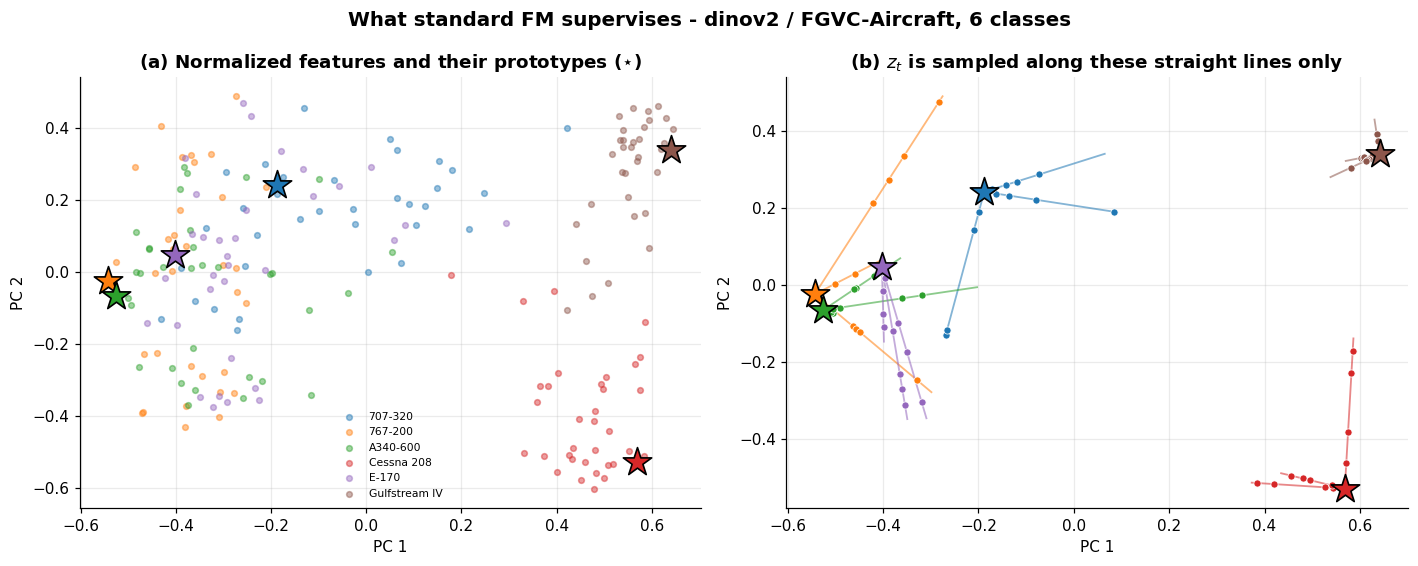

In [4]:
from sklearn.decomposition import PCA

enc, ds = "dinov2", "FGVC-Aircraft"
tr = features[(enc, ds, "train")]
protos = prototypes[proto_key(enc, ds, "full", None)]

# A readable subset: 6 classes chosen by an even stride, not hand-picked.
chosen = np.arange(0, tr.n_classes, max(1, tr.n_classes // 6))[:6]
mask = np.isin(tr.labels.numpy(), chosen)
z_sub = l2_normalize(tr.features[mask])
y_sub = tr.labels[mask]

# Fit the projection jointly over features and prototypes so both live in one space.
pca = PCA(n_components=2, random_state=0).fit(
    torch.cat([z_sub, protos[chosen]]).numpy())
Z = pca.transform(z_sub.numpy())
P = pca.transform(protos[chosen].numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
palette = plt.cm.tab10(np.linspace(0, 1, 10))

# (a) where the features and prototypes sit
ax = axes[0]
for j, c in enumerate(chosen):
    sel = (y_sub == c).numpy()
    ax.scatter(Z[sel, 0], Z[sel, 1], s=14, alpha=0.45, color=palette[j],
               label=tr.classes[c][:18])
    ax.scatter(*P[j], marker="*", s=380, color=palette[j],
               edgecolor="black", linewidth=1.1, zorder=5)
ax.set_title("(a) Normalized features and their prototypes ($\\star$)")
ax.legend(fontsize=7, loc="best")

# (b) the straight paths the loss samples from
ax = axes[1]
rng = np.random.default_rng(0)
for j, c in enumerate(chosen):
    idx = np.where((y_sub == c).numpy())[0]
    for i in rng.choice(idx, size=min(3, len(idx)), replace=False):
        ax.plot([Z[i, 0], P[j, 0]], [Z[i, 1], P[j, 1]],
                color=palette[j], alpha=0.55, lw=1.2, zorder=2)
        ts = rng.uniform(0, 1, 4)
        pts = np.outer(1 - ts, Z[i]) + np.outer(ts, P[j])
        ax.scatter(pts[:, 0], pts[:, 1], s=22, color=palette[j],
                   edgecolor="white", linewidth=0.5, zorder=3)
    ax.scatter(*P[j], marker="*", s=380, color=palette[j],
               edgecolor="black", linewidth=1.1, zorder=5)
ax.set_title("(b) $z_t$ is sampled along these straight lines only")

for ax in axes:
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

fig.suptitle(f"What standard FM supervises - {enc} / {ds}, 6 classes",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "standard_fm_concept")
plt.show()

## 4 · Train the 27 models

3 combinations $\times$ 3 training sizes $\times$ 3 seeds. Each trained model is evaluated at
**both** $T = 4$ and $T = 12$, since standard FM training never rolls out.

The k-shot subsets come from `cvlab.data.make_kshot_subset` with the same `(K, seed)` Stage 1
used, so for every cell the FM layer sees exactly the images the baseline saw.

In [5]:
run_rows: list[dict] = []
curves: dict[str, list[float]] = {}
predictions: dict[str, torch.Tensor] = {}
kept_models: dict[str, dict] = {}

sweep_start = time.perf_counter()

for enc, ds in COMBOS:
    tr = features[(enc, ds, "train")]
    te = features[(enc, ds, "test")]
    print(f"=== {enc} / {ds}  ({tr.n_classes} classes, {tr.dim}-d) ===")

    for K in K_SETTINGS:
        for seed in SEEDS:
            # Looked up per seed: k-shot prototypes depend on which images were sampled.
            # Only the full-data sets are seed-independent (proto_key maps them to "NA").
            protos = prototypes[proto_key(enc, ds, K, seed)]

            if K == "full":
                sub_x, sub_y = tr.features, tr.labels
            else:
                sub_x, sub_y = make_kshot_subset(tr.features, tr.labels, k=K, seed=seed)

            net, history, elapsed = train_standard_fm(
                sub_x, sub_y, protos, seed=seed, config=CONFIG, device=DEVICE)

            accs, preds = evaluate_flow(net, te.features, te.labels, protos,
                                        T_VALUES, device=DEVICE)

            key = f"{enc}__{ds}__K{K}__seed{seed}"
            curves[key] = history
            for T in T_VALUES:
                predictions[f"{key}__T{T}"] = preds[T]
                run_rows.append({
                    "encoder": enc, "dataset": ds, "K": str(K), "seed": seed, "T": T,
                    "method": "standard_fm",
                    "n_train": int(sub_x.shape[0]),
                    "test_acc": 100 * accs[T],
                    "final_loss": history[-1],
                    "elapsed_s": round(elapsed, 2),
                })

            if (enc, ds, K, seed) in REPRESENTATIVE:
                kept_models[key] = {k: v.cpu() for k, v in net.state_dict().items()}

            base = baseline_acc[(enc, ds, str(K))]
            print(f"  K={str(K):5s} seed={seed}  n={sub_x.shape[0]:5d}  "
                  f"loss {history[0]:.4f}->{history[-1]:.4f}  "
                  f"T4={100*accs[4]:6.2f}%  T12={100*accs[12]:6.2f}%  "
                  f"(baseline {base:.2f}%)  {elapsed:.1f}s")

runs = pd.DataFrame(run_rows)
assert len(runs) == 3 * 3 * 3 * len(T_VALUES), f"expected 54 rows, got {len(runs)}"
print(f"\n27 models, {len(runs)} evaluations in {time.perf_counter() - sweep_start:.1f}s")

=== resnet18 / DTD  (47 classes, 512-d) ===


  K=5     seed=0  n=  235  loss 0.5658->0.1613  T4= 45.64%  T12= 45.90%  (baseline 46.10%)  1.5s


  K=5     seed=1  n=  235  loss 0.5321->0.1598  T4= 43.62%  T12= 43.94%  (baseline 46.10%)  1.1s


  K=5     seed=2  n=  235  loss 0.5522->0.1644  T4= 44.15%  T12= 44.52%  (baseline 46.10%)  1.0s


  K=10    seed=0  n=  470  loss 0.5292->0.1885  T4= 50.00%  T12= 50.16%  (baseline 51.67%)  2.0s


...

  K=10    seed=1  n= 1000  loss 0.4663->0.2129  T4= 44.16%  T12= 43.32%  (baseline 27.74%)  3.9s


  K=10    seed=2  n= 1000  loss 0.4750->0.2137  T4= 42.06%  T12= 41.16%  (baseline 27.74%)  4.0s


  K=full  seed=0  n= 3334  loss 0.4053->0.1690  T4= 56.56%  T12= 56.05%  (baseline 34.26%)  13.1s


  K=full  seed=1  n= 3334  loss 0.4011->0.1785  T4= 56.23%  T12= 55.57%  (baseline 34.26%)  13.5s


  K=full  seed=2  n= 3334  loss 0.4022->0.1699  T4= 56.77%  T12= 55.48%  (baseline 34.26%)  16.0s

27 models, 54 evaluations in 156.5s


## 5 · Results against the Stage 1 baseline

$\Delta\mathrm{Acc} = \mathrm{Acc}_\mathrm{FM} - \mathrm{Acc}_\mathrm{baseline}$, computed
against the corresponding baseline cell — the same combination and the same $K$.

In [6]:
summary = (runs.groupby(["encoder", "dataset", "K", "T"], sort=False)["test_acc"]
           .agg(["mean", "std", "count"]).reset_index())
summary["baseline"] = summary.apply(
    lambda r: baseline_acc[(r.encoder, r.dataset, r.K)], axis=1)
summary["delta_pp"] = summary["mean"] - summary["baseline"]
summary = summary.round({"mean": 2, "std": 2, "baseline": 2, "delta_pp": 2})
summary["accuracy"] = summary.apply(
    lambda r: f"{r['mean']:.2f} +/- {r['std']:.2f}", axis=1)

art.table(summary, "accuracy_summary")
summary[["encoder", "dataset", "K", "T", "baseline", "accuracy", "delta_pp"]]

  saved table -> tables/accuracy_summary.csv  (18 rows)


,encoder,dataset,K,T,baseline,accuracy,delta_pp
0,resnet18,DTD,5,4,46.10,44.47 +/- 1.05,-1.63
1,resnet18,DTD,5,12,46.10,44.79 +/- 1.01,-1.31
2,resnet18,DTD,10,4,51.67,50.11 +/- 0.86,-1.56
3,resnet18,DTD,10,12,51.67,50.34 +/- 0.66,-1.33
4,resnet18,DTD,full,4,58.83,59.59 +/- 0.61,0.76
5,resnet18,DTD,full,12,58.83,59.56 +/- 0.68,0.73
6,resnet18,FGVC-Aircraft,5,4,16.46,18.81 +/- 1.01,2.35
7,resnet18,FGVC-Aircraft,5,12,16.46,18.94 +/- 1.02,2.48
8,resnet18,FGVC-Aircraft,10,4,20.19,23.68 +/- 0.39,3.49
9,resnet18,FGVC-Aircraft,10,12,20.19,23.91 +/- 0.32,3.72


  saved plot  -> plots/accuracy_vs_k.png


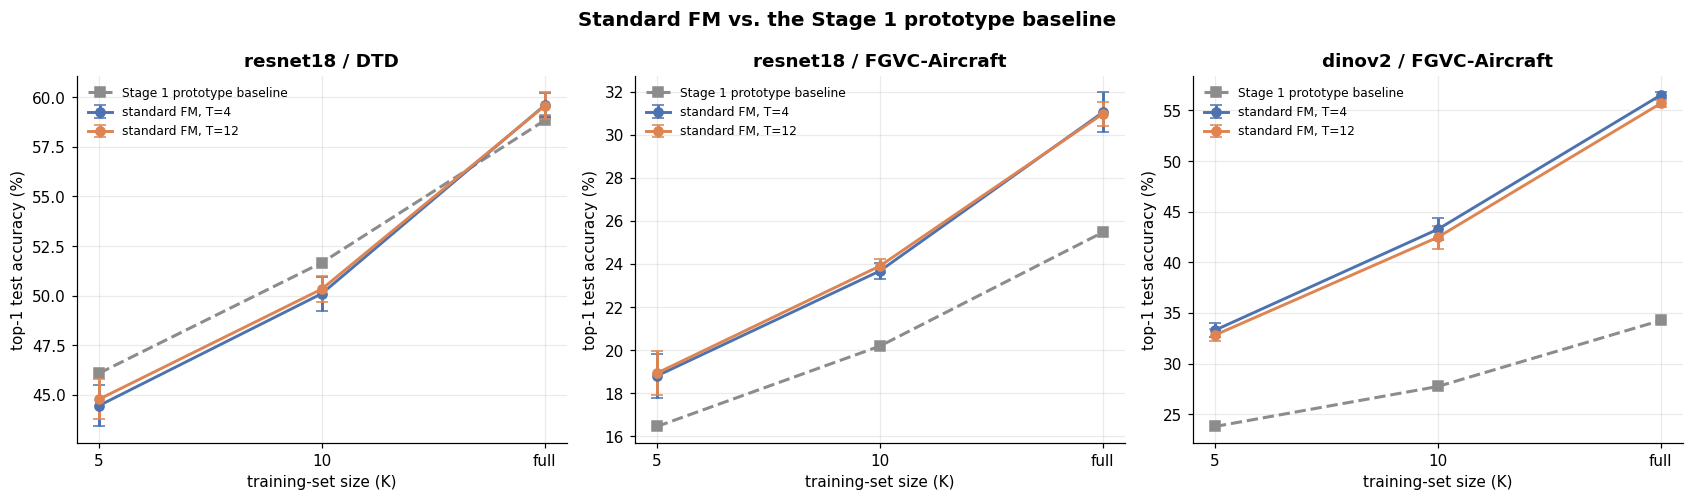

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), sharey=False)
order = ["5", "10", "full"]

for ax, (enc, ds) in zip(axes, COMBOS):
    base_vals = [baseline_acc[(enc, ds, k)] for k in order]
    ax.plot(order, base_vals, marker="s", lw=2.0, color="#8C8C8C",
            ls="--", label="Stage 1 prototype baseline")

    for T, color in zip(T_VALUES, ["#4C72B0", "#DD8452"]):
        sel = summary[(summary.encoder == enc) & (summary.dataset == ds) & (summary["T"] == T)]
        sel = sel.set_index("K").loc[order]
        ax.errorbar(order, sel["mean"], yerr=sel["std"], marker="o", capsize=4,
                    lw=1.9, color=color, label=f"standard FM, T={T}")

    ax.set_title(f"{enc} / {ds}")
    ax.set_xlabel("training-set size (K)")
    ax.set_ylabel("top-1 test accuracy (%)")
    ax.legend(fontsize=8)

fig.suptitle("Standard FM vs. the Stage 1 prototype baseline",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "accuracy_vs_k")
plt.show()

  saved plot  -> plots/delta_vs_baseline.png


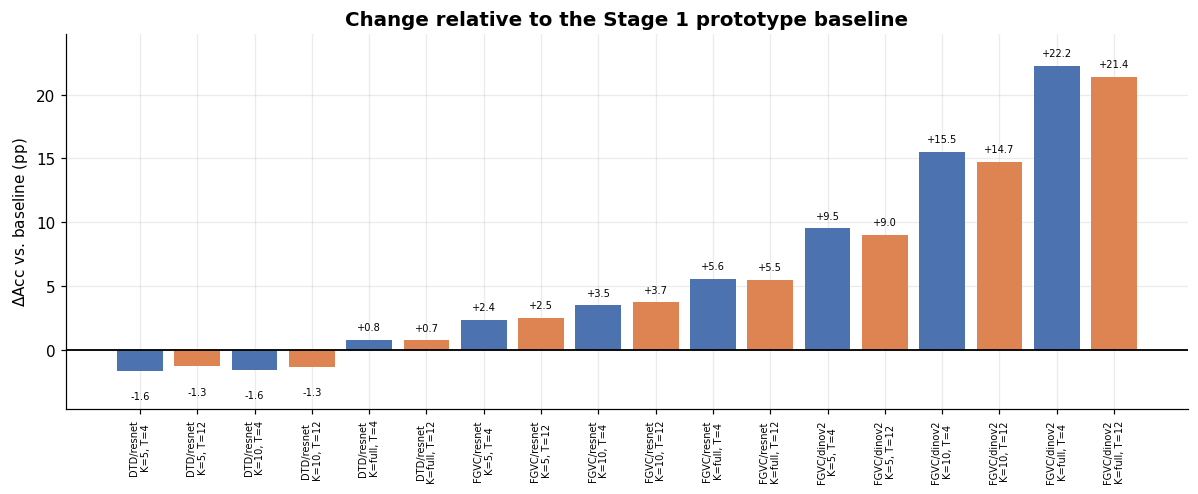

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.6))

labels, deltas, colors = [], [], []
for enc, ds in COMBOS:
    for K in order:
        for T, c in zip(T_VALUES, ["#4C72B0", "#DD8452"]):
            row = summary[(summary.encoder == enc) & (summary.dataset == ds)
                          & (summary.K == K) & (summary["T"] == T)]
            labels.append(f"{ds[:4]}/{enc[:6]}\nK={K}, T={T}")
            deltas.append(float(row["delta_pp"].iloc[0]))
            colors.append(c)

x = np.arange(len(deltas))
ax.bar(x, deltas, color=colors)
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=6.5, rotation=90)
ax.set_ylabel(r"$\Delta$Acc vs. baseline (pp)")
ax.set_title("Change relative to the Stage 1 prototype baseline",
             fontsize=13, fontweight="bold")
# Headroom so the value labels - especially the negative ones - are never clipped.
ax.set_ylim(min(deltas) - 3.0, max(deltas) + 2.5)
for xi, d in zip(x, deltas):
    ax.text(xi, d + (0.6 if d >= 0 else -1.6), f"{d:+.1f}",
            ha="center", va="bottom" if d >= 0 else "top", fontsize=6.5)
fig.tight_layout()
art.figure(fig, "delta_vs_baseline")
plt.show()

## 6 · Training curves — stability

The brief asks these curves to show that training is stable and reaches a reasonable
solution. Because no validation-based checkpointing is used (see `cvlabfm.flow` for why), the
curves are also the evidence that the fixed 100-epoch budget is enough — a loss still falling
steeply at epoch 100 would mean the budget, not the objective, was limiting the result.

  saved plot  -> plots/training_curves.png


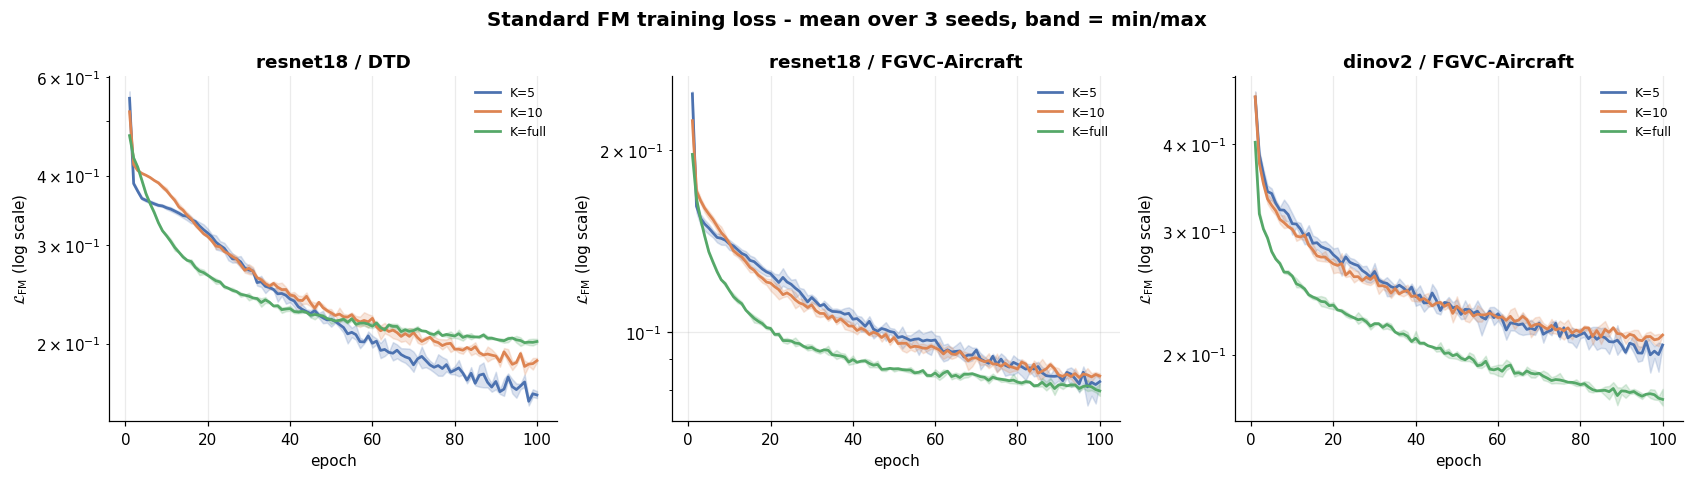

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

for ax, (enc, ds) in zip(axes, COMBOS):
    for K, color in zip(order, ["#4C72B0", "#DD8452", "#55A868"]):
        hist = np.array([curves[f"{enc}__{ds}__K{K}__seed{s}"] for s in SEEDS])
        epochs = np.arange(1, hist.shape[1] + 1)
        ax.plot(epochs, hist.mean(0), color=color, lw=1.8, label=f"K={K}")
        ax.fill_between(epochs, hist.min(0), hist.max(0), color=color, alpha=0.20)
    ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel(r"$\mathcal{L}_{\mathrm{FM}}$ (log scale)")
    ax.set_title(f"{enc} / {ds}")
    ax.legend(fontsize=8)

fig.suptitle("Standard FM training loss - mean over 3 seeds, band = min/max",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "training_curves")
plt.show()

In [10]:
# Quantify what the curves show, rather than leaving "it converged" to the eye.
stab_rows = []
for enc, ds in COMBOS:
    for K in order:
        hist = np.array([curves[f"{enc}__{ds}__K{K}__seed{s}"] for s in SEEDS])
        first, last = hist[:, 0].mean(), hist[:, -1].mean()
        last_decile = hist[:, -10:].mean(1)
        prev_decile = hist[:, -20:-10].mean(1)
        improvement = (prev_decile - last_decile) / prev_decile * 100
        stab_rows.append({
            "encoder": enc, "dataset": ds, "K": K,
            "loss_start": round(float(first), 4),
            "loss_end": round(float(last), 4),
            "reduction_%": round(float((first - last) / first * 100), 1),
            "last_10ep_improvement_%": round(float(improvement.mean()), 3),
            "seed_spread_end": round(float(hist[:, -1].std()), 5),
            "monotone": bool(np.all(np.diff(hist.mean(0)[::5]) <= 1e-6)),
        })

stability = pd.DataFrame(stab_rows)
art.table(stability, "training_stability")
stability

  saved table -> tables/training_stability.csv  (9 rows)


,encoder,dataset,K,loss_start,loss_end,reduction_%,last_10ep_improvement_%,seed_spread_end,monotone
0,resnet18,DTD,5,0.5500,0.1619,70.6,4.569,0.00192,False
1,resnet18,DTD,10,0.5203,0.1864,64.2,3.647,0.00148,False
2,resnet18,DTD,full,0.4715,0.2018,57.2,1.576,0.00158,False
3,resnet18,FGVC-Aircraft,5,0.2481,0.0827,66.7,3.060,0.00073,False
4,resnet18,FGVC-Aircraft,10,0.2239,0.0845,62.3,2.687,0.00064,False
5,resnet18,FGVC-Aircraft,full,0.1969,0.0798,59.5,0.955,0.00159,False
6,dinov2,FGVC-Aircraft,5,0.4675,0.2064,55.9,3.389,0.00043,False
7,dinov2,FGVC-Aircraft,10,0.4682,0.2133,54.4,1.909,0.00033,False
8,dinov2,FGVC-Aircraft,full,0.4029,0.1725,57.2,1.543,0.00430,True


## 6b · Ablation — was L2 normalization actually necessary?

Step 1 argued for normalizing the features from geometry alone: with raw features the target
$u = p - z$ is 99.99 % aligned with $-z$, so the prototype carries almost no signal. That is
an argument, not a measurement — and this project's own standard (Stage 1 ablated the banner
crop rather than assuming it) is to test such decisions.

So: train the identical objective on **raw, unnormalized** features and compare. Everything
else is held fixed — same architecture, same optimiser, same seed, same prototypes, same
epochs. Classification is cosine-based and therefore scale-invariant, so the comparison is
fair.

In [11]:
ablation_rows = []

for enc, ds in COMBOS:
    tr, te = features[(enc, ds, "train")], features[(enc, ds, "test")]
    protos = prototypes[proto_key(enc, ds, "full", None)]

    for normalize in (True, False):
        net, history, _ = train_standard_fm(
            tr.features, tr.labels, protos, seed=0, config=CONFIG,
            device=DEVICE, normalize=normalize)
        accs, _ = evaluate_flow(net, te.features, te.labels, protos, T_VALUES,
                                device=DEVICE, normalize=normalize)
        ablation_rows.append({
            "encoder": enc, "dataset": ds,
            "input": "L2-normalized" if normalize else "raw",
            "baseline": baseline_acc[(enc, ds, "full")],
            "acc_T4": round(100 * accs[4], 2),
            "acc_T12": round(100 * accs[12], 2),
            "final_loss": round(history[-1], 4),
        })

ablation = pd.DataFrame(ablation_rows)
ablation["vs_baseline_T4"] = (ablation.acc_T4 - ablation.baseline).round(2)
art.table(ablation, "normalization_ablation")
ablation

  saved table -> tables/normalization_ablation.csv  (6 rows)


,encoder,dataset,input,baseline,acc_T4,acc_T12,final_loss,vs_baseline_T4
0,resnet18,DTD,L2-normalized,58.8298,58.88,58.78,0.2039,0.05
1,resnet18,DTD,raw,58.8298,38.56,42.71,44.3850,-20.27
2,resnet18,FGVC-Aircraft,L2-normalized,25.4725,31.53,31.26,0.0783,6.06
3,resnet18,FGVC-Aircraft,raw,25.4725,15.78,17.55,27.1273,-9.69
4,dinov2,FGVC-Aircraft,L2-normalized,34.2634,56.56,56.05,0.1690,22.30
5,dinov2,FGVC-Aircraft,raw,34.2634,37.92,40.62,110.7453,3.66


  saved plot  -> plots/normalization_ablation.png


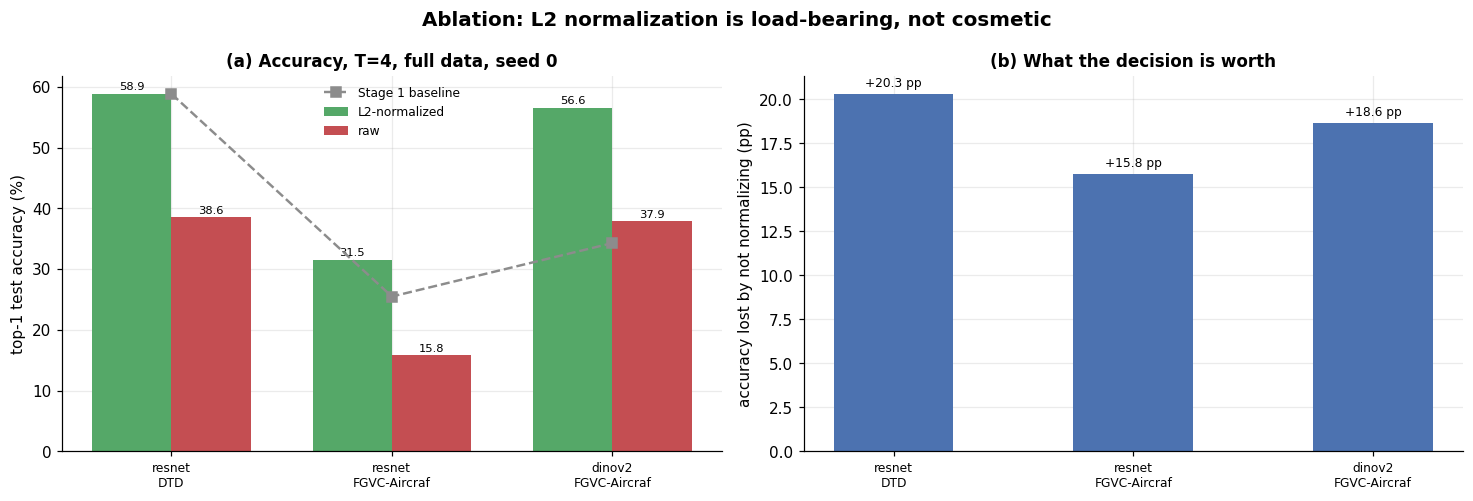

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

labels = [f"{e[:6]}\n{d[:12]}" for e, d in COMBOS]
x = np.arange(len(COMBOS))

ax = axes[0]
for i, (inp, c) in enumerate([("L2-normalized", "#55A868"), ("raw", "#C44E52")]):
    vals = [ablation[(ablation.encoder == e) & (ablation.dataset == d)
                     & (ablation.input == inp)].acc_T4.iloc[0] for e, d in COMBOS]
    bars = ax.bar(x + (i - 0.5) * 0.36, vals, 0.36, color=c, label=inp)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.6, f"{v:.1f}", ha="center", fontsize=7.5)
base_vals = [baseline_acc[(e, d, "full")] for e, d in COMBOS]
ax.plot(x, base_vals, marker="s", ls="--", lw=1.6, color="#8C8C8C",
        label="Stage 1 baseline", zorder=5)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("top-1 test accuracy (%)")
ax.set_title("(a) Accuracy, T=4, full data, seed 0", fontsize=11)
ax.legend(fontsize=8)

ax = axes[1]
cost = [ablation[(ablation.encoder == e) & (ablation.dataset == d)
                 & (ablation.input == "L2-normalized")].acc_T4.iloc[0]
        - ablation[(ablation.encoder == e) & (ablation.dataset == d)
                   & (ablation.input == "raw")].acc_T4.iloc[0] for e, d in COMBOS]
bars = ax.bar(x, cost, 0.5, color="#4C72B0")
for b, v in zip(bars, cost):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.4, f"{v:+.1f} pp", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("accuracy lost by not normalizing (pp)")
ax.set_title("(b) What the decision is worth", fontsize=11)

fig.suptitle("Ablation: L2 normalization is load-bearing, not cosmetic",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "normalization_ablation")
plt.show()

**The decision is worth 18–22 pp.** On raw features the flow lands *below* the Stage 1
prototype baseline on every combination — it actively destroys accuracy — and its final loss
sits in the tens or hundreds rather than below 1, because the target $u = p - z$ inherits the
feature's magnitude (norms 24–50).

This turns the step 1 argument into a measured result: normalizing is not a stylistic
preference, it is what makes the FM layer work at all.

## 7 · Save artefacts

Full weights are kept only for the three representative runs (full data, seed 0) that step 5
visualises — 27 sets would be ~85 MB of regenerable data. Everything needed for the
comparison in step 4 (accuracies, curves, predictions) is saved in full.

In [13]:
runs.to_csv(RESULTS_ROOT / "standard_fm_runs.csv", index=False)
with open(RESULTS_ROOT / "standard_fm_curves.json", "w") as f:
    json.dump(curves, f)
torch.save(predictions, RESULTS_ROOT / "standard_fm_predictions.pt")
torch.save({"state_dicts": kept_models,
            "config": CONFIG.as_dict(),
            "note": "full-data seed-0 runs, kept for step 5 visualisations"},
           RESULTS_ROOT / "standard_fm_models.pt")

for name in ("standard_fm_runs.csv", "standard_fm_curves.json",
             "standard_fm_predictions.pt", "standard_fm_models.pt"):
    kb = (RESULTS_ROOT / name).stat().st_size / 1024
    print(f"  results/{name:34s} {kb:9.1f} KB")

methodology = pd.DataFrame([
    {"item": "objective", "value": "L_FM = ||v(z_t, t) - u||^2,  z_t = (1-t) z + t p,  u = p - z"},
    {"item": "flow input", "value": "L2-normalized features (step 1)"},
    {"item": "prototypes", "value": "step 1 results/prototypes.pt - verified against Stage 1"},
    {"item": "k-shot subsets", "value": "cvlab.data.make_kshot_subset - identical to Stage 1"},
    {"item": "architecture", "value": f"MLP, {CONFIG.n_hidden} x {CONFIG.hidden_dim}, SiLU, t concatenated"},
    {"item": "optimiser", "value": f"{CONFIG.optimizer}, lr {CONFIG.lr}, wd {CONFIG.weight_decay}, batch {CONFIG.batch_size}"},
    {"item": "gradient clipping", "value": f"norm {CONFIG.max_grad_norm} - applied to BOTH objectives so they stay configuration-identical"},
    {"item": "epochs", "value": f"{CONFIG.epochs} (fixed budget, no checkpoint selection)"},
    {"item": "models trained", "value": "27 = 3 combos x 3 K x 3 seeds (+6 for the normalization ablation)"},
    {"item": "normalization", "value": "L2-normalized inputs; ablated in section 6b (raw costs 18-22 pp)"},
    {"item": "T dependence", "value": "none at training time - each model evaluated at T=4 and T=12"},
    {"item": "classification", "value": "argmax_c cos(z_T, mu_c) - unchanged from Stage 1"},
])
art.table(methodology, "methodology")
methodology

  results/standard_fm_runs.csv                     4.7 KB


  results/standard_fm_curves.json                 55.5 KB
  results/standard_fm_predictions.pt            1217.8 KB
  results/standard_fm_models.pt                 8733.8 KB
  saved table -> tables/methodology.csv  (12 rows)


,item,value
0,objective,"L_FM = ||v(z_t, t) - u||^2, z_t = (1-t) z + t..."
1,flow input,L2-normalized features (step 1)
2,prototypes,step 1 results/prototypes.pt - verified agains...
3,k-shot subsets,cvlab.data.make_kshot_subset - identical to St...
4,architecture,"MLP, 2 x 512, SiLU, t concatenated"
5,optimiser,"AdamW, lr 0.001, wd 0.0001, batch 64"
6,gradient clipping,norm 1.0 - applied to BOTH objectives so they ...
7,epochs,"100 (fixed budget, no checkpoint selection)"
8,models trained,27 = 3 combos x 3 K x 3 seeds (+6 for the norm...
9,normalization,L2-normalized inputs; ablated in section 6b (r...


## 8 · Manifest

In [14]:
art.manifest()

10 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\Work\02_standard_fm


,kind,file,size_KB
0,plot,plots/accuracy_vs_k.png,141.1
1,plot,plots/delta_vs_baseline.png,49.2
2,plot,plots/normalization_ablation.png,78.5
3,plot,plots/standard_fm_concept.png,140.9
4,plot,plots/training_curves.png,222.2
5,table,tables/accuracy_summary.csv,1.2
6,table,tables/architecture.csv,0.2
7,table,tables/methodology.csv,0.8
8,table,tables/normalization_ablation.csv,0.4
9,table,tables/training_stability.csv,0.6


---

## Next step

**Step 3 — Rolled-out FM training.** Same network, same configuration, same subsets and
seeds; only the objective changes:

$$\mathcal{L}_\mathrm{roll} = \lVert \hat z_T - p_{y_i} \rVert_2^2$$

with gradients flowing back through the complete $T$-step rollout. Because $T$ is part of
training there, a separate model is needed per $T$ — 54 models rather than 27.